## Install libraries

In [1]:
pip install shap xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import libraries

In [3]:
import matplotlib.pylab as pl
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
import shap

# print the JS visualization code to the notebook
shap.initjs()

## Import dataset

In [4]:
X, y = shap.datasets.adult()
X_display, y_display = shap.datasets.adult(display=True)

In [5]:
print(X_display)

        Age          Workclass  Education-Num       Marital Status  \
0      39.0          State-gov           13.0        Never-married   
1      50.0   Self-emp-not-inc           13.0   Married-civ-spouse   
2      38.0            Private            9.0             Divorced   
3      53.0            Private            7.0   Married-civ-spouse   
4      28.0            Private           13.0   Married-civ-spouse   
...     ...                ...            ...                  ...   
32556  27.0            Private           12.0   Married-civ-spouse   
32557  40.0            Private            9.0   Married-civ-spouse   
32558  58.0            Private            9.0              Widowed   
32559  22.0            Private            9.0        Never-married   
32560  52.0       Self-emp-inc            9.0   Married-civ-spouse   

               Occupation    Relationship    Race      Sex  Capital Gain  \
0            Adm-clerical   Not-in-family   White     Male        2174.0   
1      

In [6]:
print(y_display)

[False False False ... False False  True]


## Create test-train split

In [7]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
d_train = xgboost.DMatrix(X_train, label=y_train)
d_test = xgboost.DMatrix(X_test, label=y_test)

In [8]:
print(X.shape)

(32561, 12)


In [9]:
print(X_train)

        Age  Workclass  Education-Num  Marital Status  Occupation  \
12011  51.0          4           10.0               0           6   
23599  51.0          1           14.0               6          12   
23603  21.0          4           11.0               4           3   
6163   25.0          4           10.0               4          12   
14883  48.0          4           13.0               0           1   
...     ...        ...            ...             ...         ...   
5699   23.0          4            9.0               4          12   
10742  37.0          4            9.0               2           7   
16921  27.0          6            5.0               2           3   
25796  46.0          4           16.0               2          10   
28847  55.0          4           10.0               0          13   

       Relationship  Race  Sex  Capital Gain  Capital Loss  Hours per week  \
12011             0     4    0           0.0           0.0            40.0   
23599          

In [10]:
print(X_train.shape)

(26048, 12)


## Define parameters for xgboost

In [11]:
params = {
    "eta": 0.01,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}
model = xgboost.train(
    params,
    d_train,
    5000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=20,
)

[0]	test-logloss:0.54658


[100]	test-logloss:0.36371


[200]	test-logloss:0.31781


[300]	test-logloss:0.30078


[400]	test-logloss:0.29175


[500]	test-logloss:0.28669


[600]	test-logloss:0.28339


[700]	test-logloss:0.28154


[800]	test-logloss:0.28015


[900]	test-logloss:0.27935


[1000]	test-logloss:0.27899


[1100]	test-logloss:0.27861


[1133]	test-logloss:0.27856


## Print accuracy

In [12]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred_prob = model.predict(d_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 87.46%


## SHAP explainer

In [13]:
# This takes 5-6 minutes since we are explaining over 30
#thousand samples in a model with over a thousand trees
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

## SHAP force plot
A SHAP force plot explains why a machine-learning model made one particular prediction 

In [14]:
import plotly.io as pio

# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(explainer.expected_value, shap_values[50, :], X_display.iloc[50, :])


In [15]:
# Index of the sample you are interested in
sample_index = 49

# Get feature names
feature_names = X_display.columns

# Get SHAP values for that sample
shap_values_sample = shap_values[sample_index]

# Get the actual feature values for that sample
feature_values = X_display.iloc[sample_index]

# Print SHAP value for each feature
for name, value, shap_val in zip(feature_names, feature_values, shap_values_sample):
    if isinstance(value, (int, float)):  # If it's a number, format it
        val_str = f"{value:10.4f}"
    else:  # Otherwise just print the string
        val_str = f"{str(value):>10}"

    print(f"Feature: {name:20s} | Value: {val_str} | SHAP Value: {shap_val:+.4f}")


Feature: Age                  | Value:       29.0 | SHAP Value: -0.2656
Feature: Workclass            | Value:    Private | SHAP Value: +0.0045
Feature: Education-Num        | Value:       11.0 | SHAP Value: -0.0128
Feature: Marital Status       | Value:  Never-married | SHAP Value: -0.2511
Feature: Occupation           | Value:  Prof-specialty | SHAP Value: +0.2921
Feature: Relationship         | Value:  Not-in-family | SHAP Value: -1.0934
Feature: Race                 | Value:      White | SHAP Value: +0.0200
Feature: Sex                  | Value:       Male | SHAP Value: +0.1354
Feature: Capital Gain         | Value:        0.0 | SHAP Value: -0.1935
Feature: Capital Loss         | Value:        0.0 | SHAP Value: -0.0552
Feature: Hours per week       | Value:       43.0 | SHAP Value: +0.2967
Feature: Country              | Value:  United-States | SHAP Value: +0.0160


In [16]:
# Set the default renderer for Plotly to 'colab'
pio.renderers.default = 'colab'

# print the JS visualization code to the notebook
shap.initjs()  # Ensure this line is uncommented

shap.force_plot(
    explainer.expected_value, shap_values[:1000, :], X_display.iloc[:1000, :]
)

## SHAP summary plot
The purpose of shap.summary_plot(shap_values, X_display, plot_type="bar") is to provide a global explanation of your model by showing which features are most important overall across the dataset.

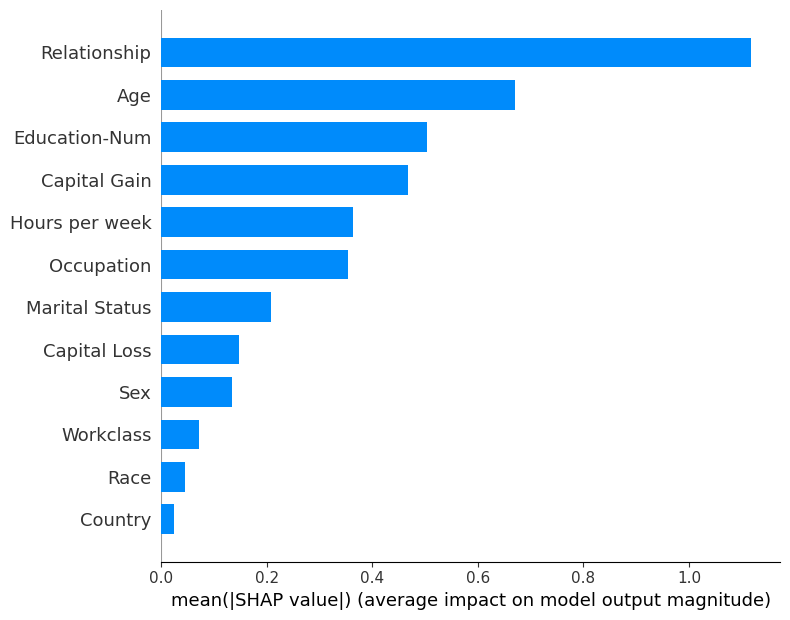

In [17]:
shap.summary_plot(shap_values, X_display, plot_type="bar")

## SHAP dependence plot
A SHAP dependence plot shows how the value of one feature affects the model prediction across many observations.

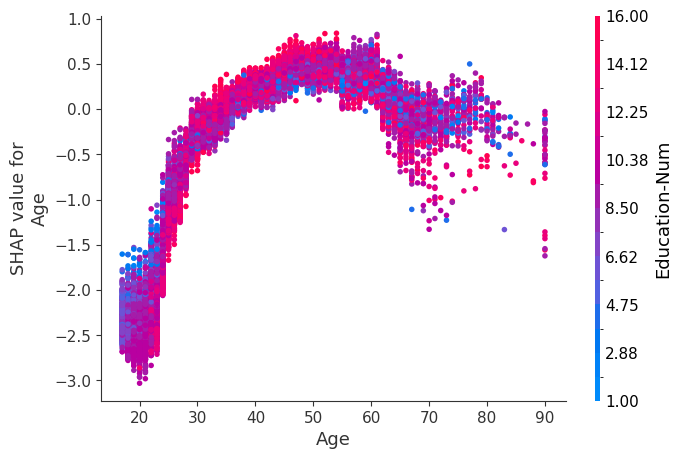

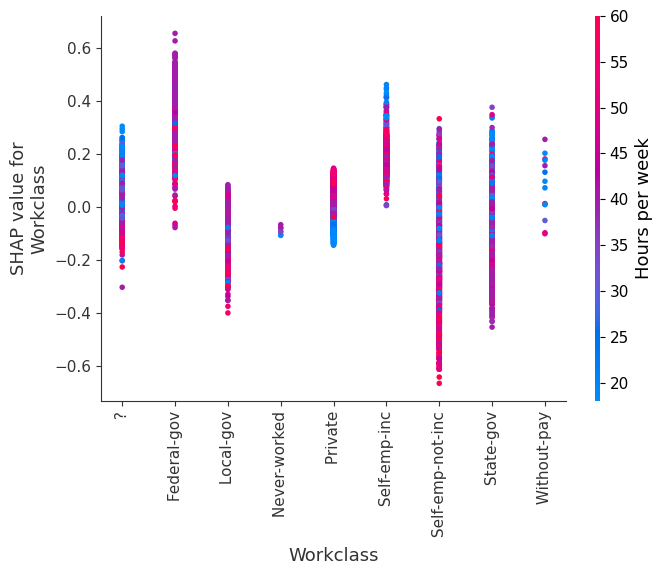

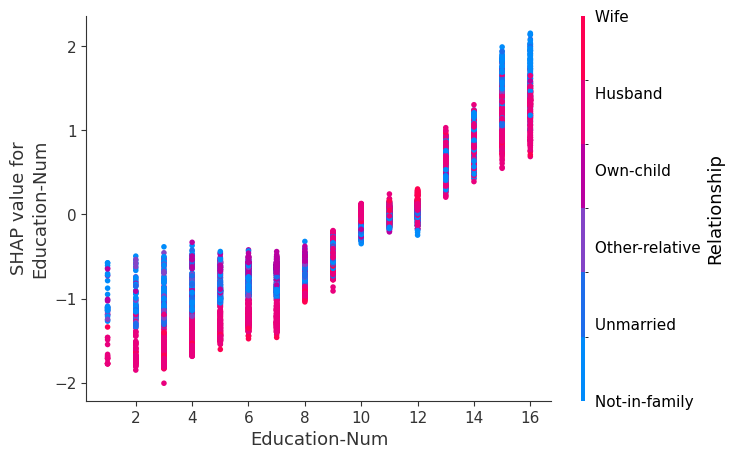

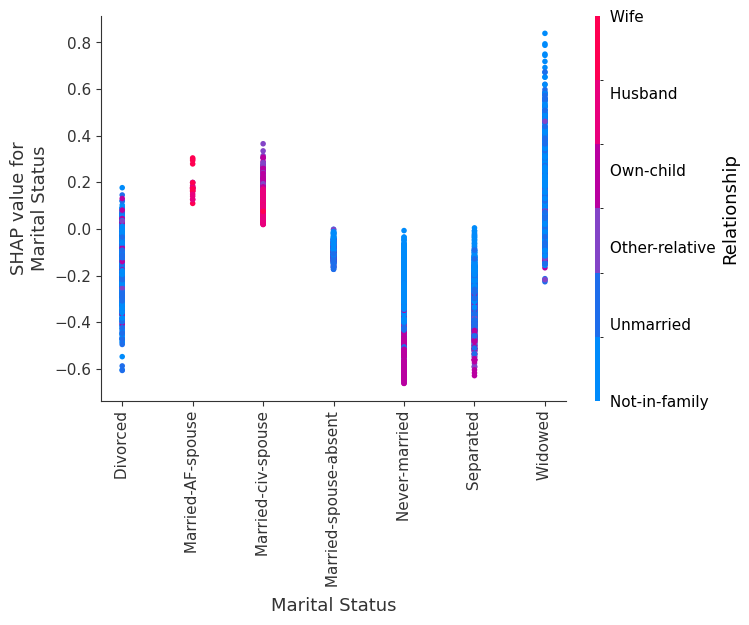

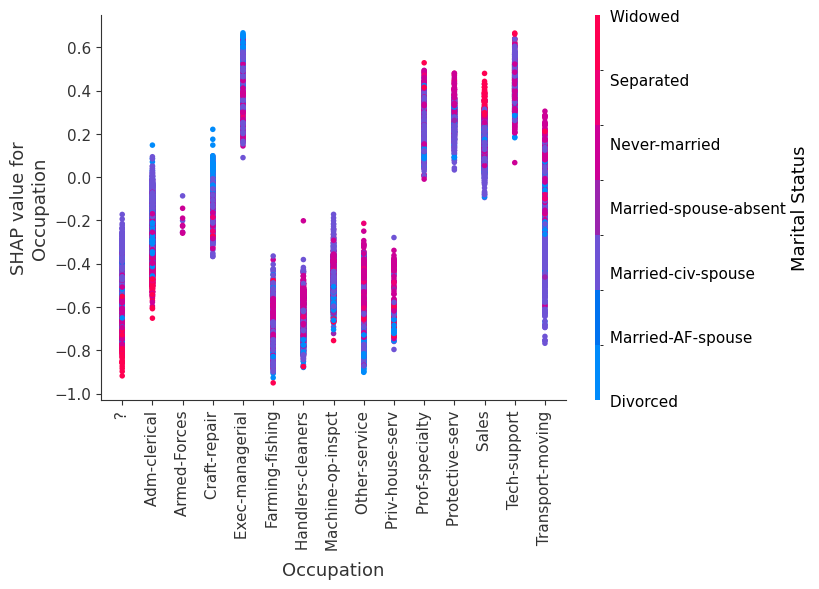

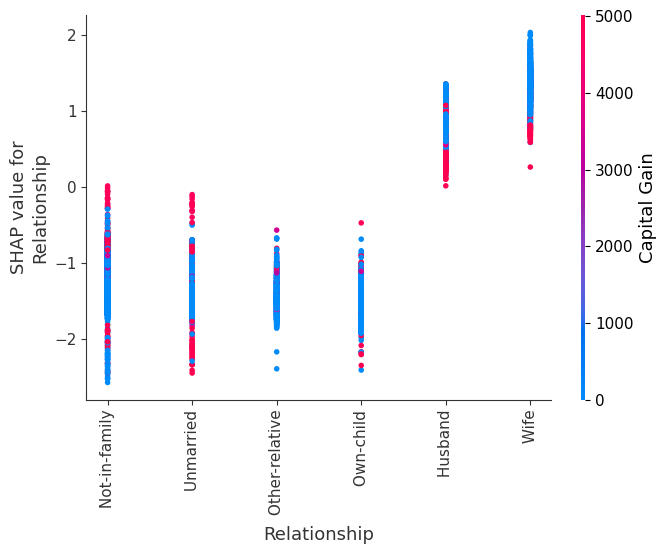

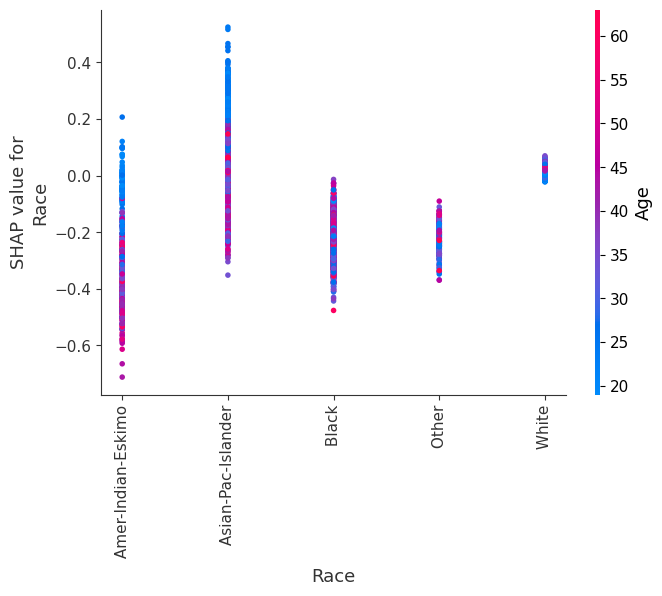

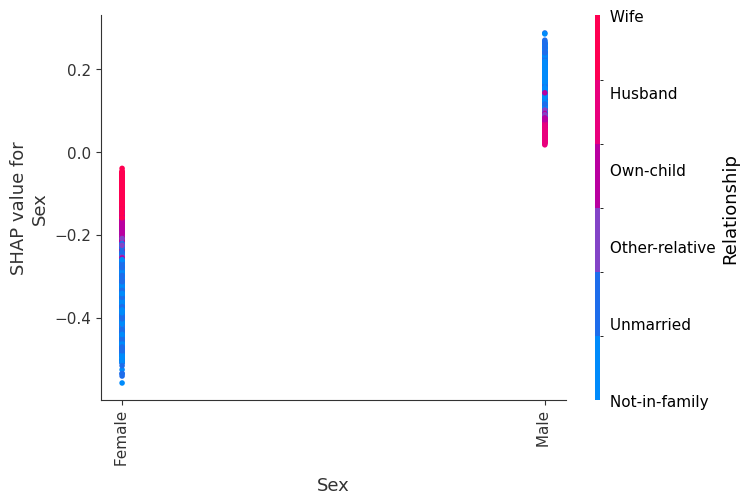

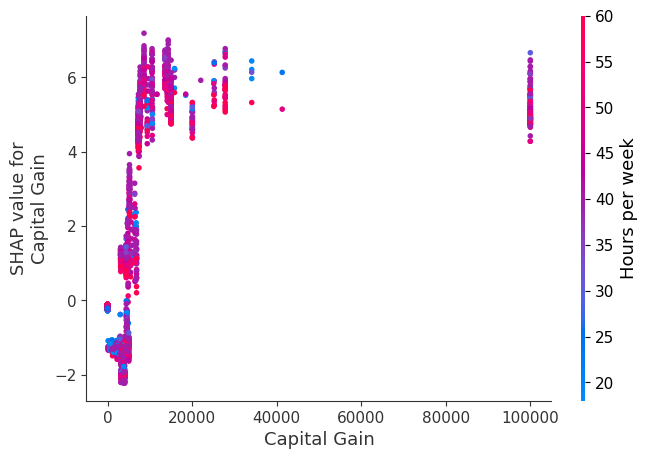

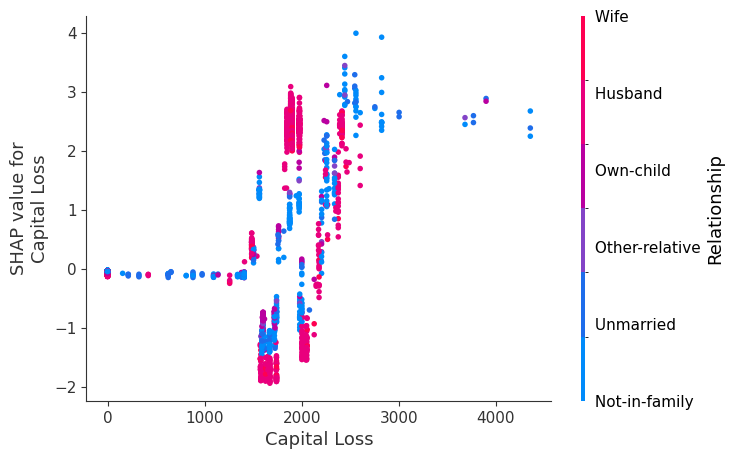

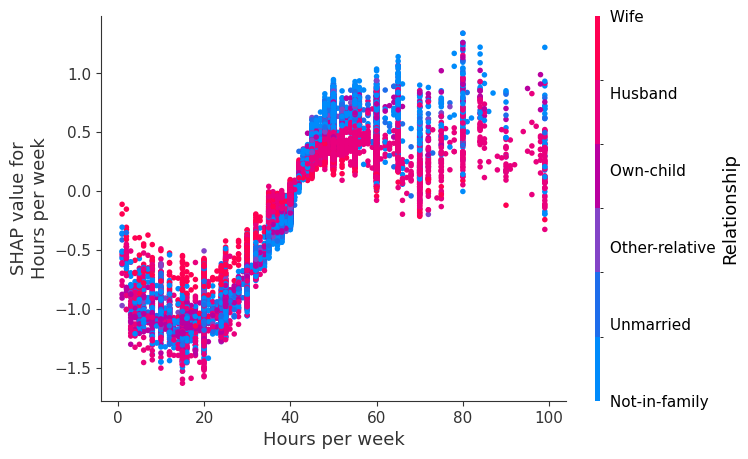

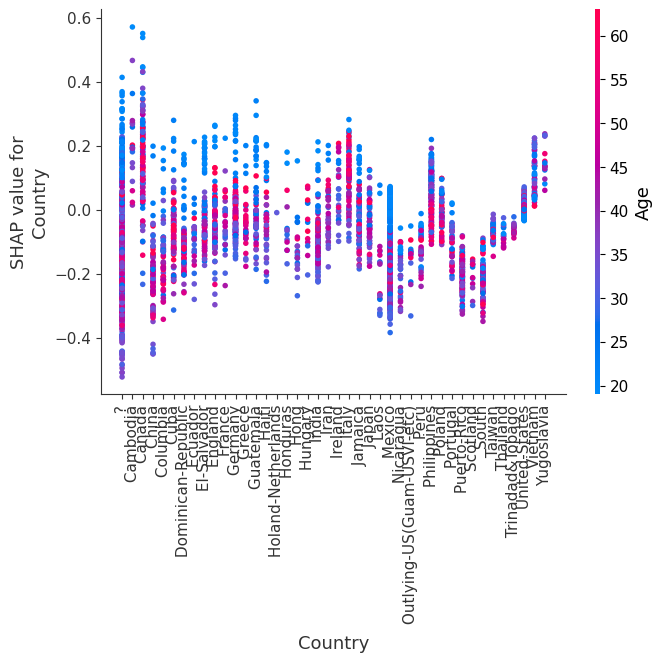

In [18]:
for name in X_train.columns:
    shap.dependence_plot(name, shap_values, X, display_features=X_display)

SHAP beeswarm plot, which is one of the most useful plots for getting a global overview of a machine-learning model.

It answers two questions at the same time:

Which features are most important overall?
For each feature, do its values push predictions higher or lower?

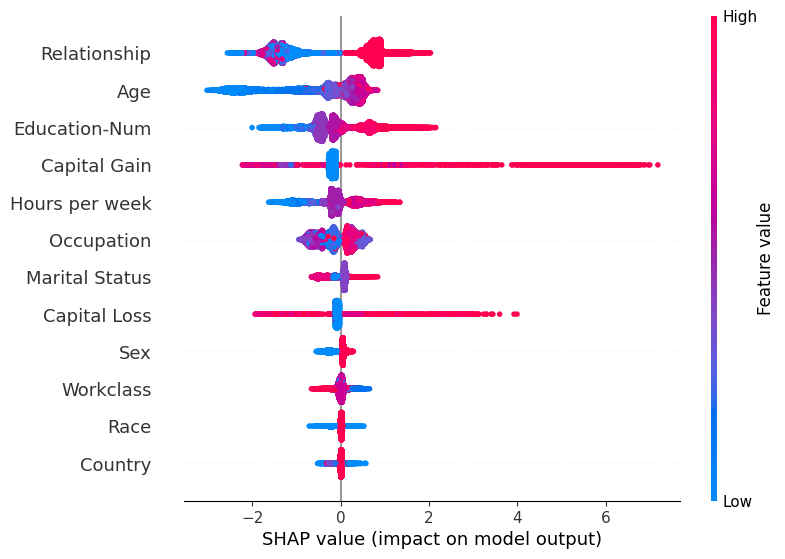

In [19]:
shap_exp = explainer(X)

shap.plots.beeswarm(
    shap_exp,
    max_display=15
)

A SHAP waterfall plot explains why the model made a particular prediction for one observation.

The easiest way to understand it is:

Start with the base value → add/subtract each feature's SHAP contribution → arrive at the final prediction \(f(x)\).

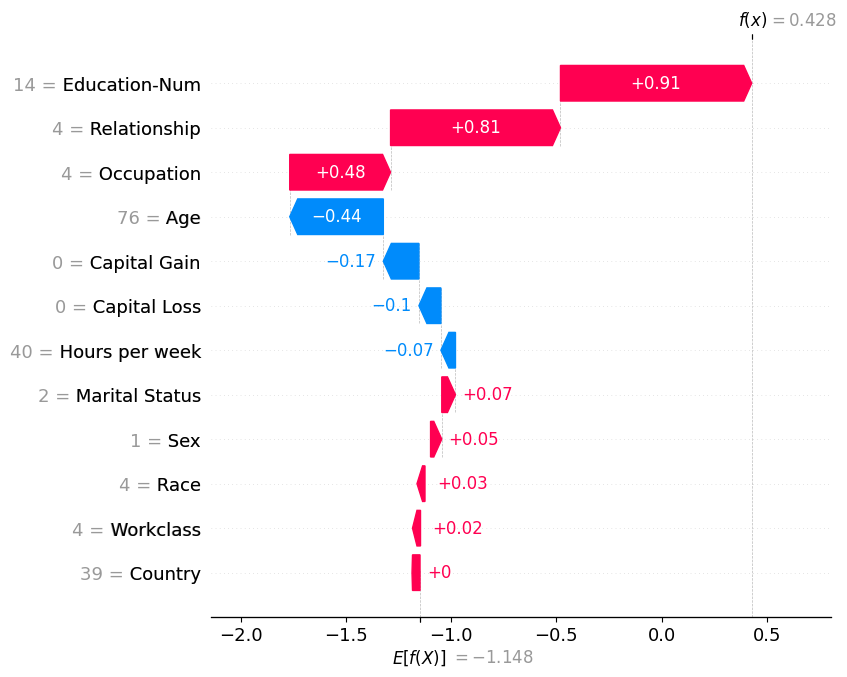

In [20]:
# 4. Waterfall plot
shap.plots.waterfall(shap_exp[100], max_display=15)

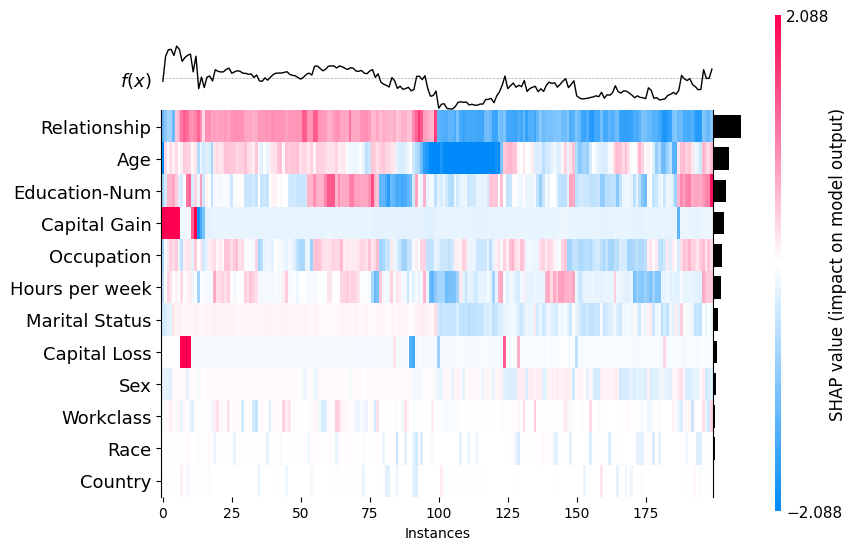

<Axes: xlabel='Instances'>

In [21]:
# 3. Heatmap
shap.plots.heatmap(shap_exp[:200], max_display=15)

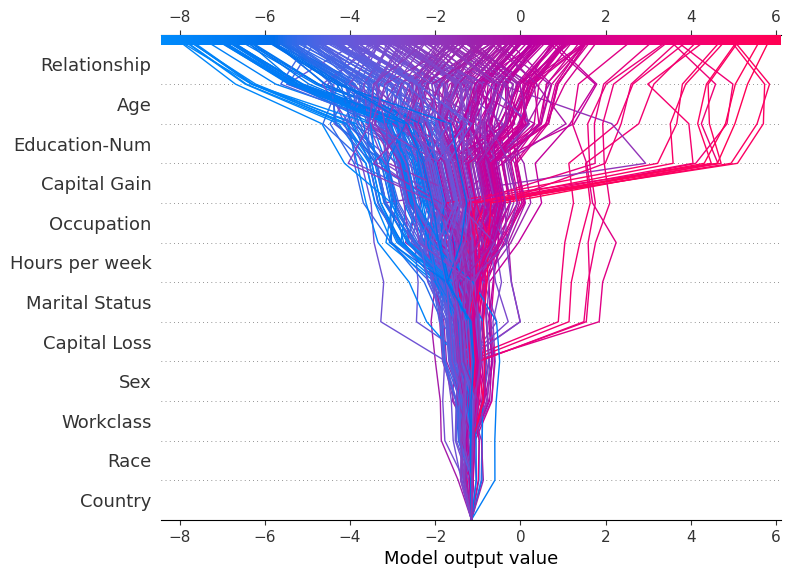

In [22]:
import shap
import matplotlib.pyplot as plt

# Create a smaller sample for a clear plot
X_sample = X.iloc[:300]
shap_sample = shap_values[:300]

shap.decision_plot(
    explainer.expected_value,
    shap_sample,
    X_sample
)



# Explainable AI Using SHAP

### Dataset

Use the **Breast Cancer Wisconsin Diagnostic Dataset** available through `scikit-learn` to build a machine learning model for classifying breast tumours as **malignant or benign** based on their measured characteristics.

### Objective

In this experiment, apply **SHAP (SHapley Additive exPlanations)** as an Explainable AI (XAI) technique to understand how individual features contribute to the predictions made by the trained machine learning model.

The following SHAP visualizations should be used:

* **SHAP Bar Plot** – to identify the globally most important features.
* **SHAP Summary/Beeswarm Plot** – to understand the direction, magnitude, and distribution of feature effects.
* **SHAP Waterfall Plot** – to explain the contribution of features for an individual prediction.
* **SHAP Dependence Plot** – to understand how a feature affects model predictions across different feature values.
* **SHAP Force Plot** – to visualize how features push an individual prediction toward malignant or benign.

---

### Task 1: Load and Prepare the Dataset

* Load the Breast Cancer Wisconsin Diagnostic dataset using `sklearn.datasets`.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Display the feature names.
* Display the target classes.
* Display descriptive statistics of the input features.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

**Comment:**

Explain the structure of the dataset, the target variable, and the purpose of separating the data into training and testing sets.

---

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm for classifying breast tumours.
* Train the model using the training dataset.
* Generate predictions for the test dataset.
* Generate prediction probabilities.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

Use a classification model such as **Random Forest Classifier**.

**Comment:**

Explain why the selected machine learning algorithm is appropriate for this dataset and discuss the obtained model performance.

---

### Task 3: Create a SHAP Explainer

* Import the SHAP library.
* Create an appropriate SHAP explainer for the trained machine learning model.
* Calculate the SHAP values for the test dataset.
* Examine the shape of the generated SHAP values.

**Comment:**

Explain:

1. What SHAP stands for.
2. What a SHAP value represents.
3. What a positive SHAP value indicates.
4. What a negative SHAP value indicates.
5. What a SHAP value close to zero means.
6. Why SHAP can be used to explain machine learning predictions.

---

### Task 4: SHAP Feature Importance – Bar Plot

Generate a **SHAP bar plot** showing the global importance of the input features.

* Calculate the mean absolute SHAP value for each feature.
* Rank the features according to their SHAP importance.
* Display the most important features using a bar chart.

**Comment:**

Identify the **top five most important features** and explain how the SHAP bar plot helps in understanding the **global behaviour** of the trained model.

---

### Task 5: SHAP Summary / Beeswarm Plot

Generate a **SHAP summary (beeswarm) plot** for the input features.

Use the plot to investigate:

* Feature importance
* SHAP value magnitude
* Positive and negative feature effects
* High and low feature values
* Distribution of SHAP values

**Comment:**

For the three most important features, explain:

1. How high feature values affect the prediction.
2. How low feature values affect the prediction.
3. Whether the feature generally pushes the prediction toward malignant or benign.
4. Whether the relationship appears linear or nonlinear.

---

### Task 6: SHAP Waterfall Plot

Select at least **one individual tumour sample** from the test dataset.

Generate a **SHAP waterfall plot** to explain its prediction.

Display:

* The base/expected value.
* Individual feature contributions.
* Features that push the prediction toward malignant.
* Features that push the prediction toward benign.
* The final model prediction.

**Comment:**

Explain how each important feature contributes to the prediction of the selected tumour sample.

---

### Task 7: SHAP Force Plot

Generate a **SHAP force plot** for the same individual sample used in Task 6.

**Comment:**

Explain:

1. Which features push the prediction toward malignant?
2. Which features push the prediction toward benign?
3. Which feature has the largest contribution?
4. How does the force plot represent the movement from the base value to the final prediction?

Compare the force plot with the waterfall plot.

---

### Task 8: SHAP Dependence Plot

Generate SHAP dependence plots for three important features identified from the SHAP analysis.

For example:

* `mean radius`
* `mean perimeter`
* `mean concavity`

**Comment:**

For each feature, explain:

1. How the feature value affects the SHAP value.
2. Whether increasing the feature increases or decreases the prediction.
3. Whether the relationship is linear or nonlinear.
4. Whether the effect changes at different feature values.
5. Whether any possible feature interaction can be observed.

---

### Task 9: Compare SHAP Explanations for Different Samples

Select at least **three different tumour samples** from the test dataset.

Generate SHAP explanations for each sample.

Compare their predictions and feature contributions.

**Comment:**

Explain:

1. Why can the same feature have different SHAP values for different samples?
2. Which features are consistently important?
3. Which features show different effects across samples?
4. How does this demonstrate the difference between **global and local explanations**?

---

### Task 10: Compare SHAP with Model Feature Importance

Calculate the built-in feature importance of the Random Forest model.

Compare it with the SHAP feature importance obtained in Task 4.

**Comment:**

Discuss:

1. Are the top-ranked features the same?
2. If there are differences, why might they occur?
3. What additional information does SHAP provide?
4. Why is feature importance alone insufficient for understanding individual predictions?

---

### Task 11: Compare Different SHAP Plots

Compare the following SHAP visualizations:

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment:**

Explain why different SHAP plots are required to obtain a complete understanding of the machine learning model.

---

### Task 12: Global vs Local Explainability

Using the SHAP plots generated in the previous tasks, explain the difference between:

**Global Explanation**

> How does the model generally classify breast tumour samples?

**Local Explanation**

> Why did the model classify this particular tumour sample as malignant or benign?

**Comment:**

Use examples from the SHAP bar/beeswarm plots and waterfall/force plots to support your explanation.

---

### Task 13: Analyse Feature Interactions

Use SHAP dependence analysis to investigate whether two important features interact with each other.

**Comment:**

Discuss:

1. Which two features appear to interact?
2. How does one feature influence the effect of another feature?
3. Why are feature interactions important for understanding model behaviour?
4. Can the effect of a feature change depending on the value of another feature?

---

### Task 14: SHAP-Based Model Analysis

Based on all the SHAP visualizations, identify:

* The five most important features.
* The feature that has the strongest positive contribution toward the predicted class.
* The feature that has the strongest negative contribution.
* Features with nonlinear effects.
* Features that show possible interactions.
* Features that consistently influence individual predictions.

**Comment:**

Explain how the SHAP analysis provides a deeper understanding of the model than simply looking at classification accuracy.

---

### Task 15: Explain a Misclassified Sample

Identify at least **one incorrectly classified sample** from the test dataset.

Generate a SHAP waterfall plot for the misclassified sample.

**Comment:**

Explain:

1. What was the actual class?
2. What class did the model predict?
3. Which features contributed most strongly to the incorrect prediction?
4. Were there features pushing the prediction toward the correct class?
5. What does the SHAP explanation reveal about the model's error?

---

### Task 16: Explain a Correctly Classified Sample

Select one correctly classified sample from the test dataset.

Generate a SHAP waterfall plot.

Compare this explanation with the misclassified sample from Task 15.

**Comment:**

Discuss how the feature contributions differ between the correctly classified and incorrectly classified samples.

---

### Final Observation

Write a short conclusion explaining how **SHAP provides both global and local explanations** of a trained machine learning model for breast cancer classification.

Your conclusion should discuss:

* Overall feature importance.
* Direction of feature effects.
* Individual feature contributions.
* Differences between individual tumour samples.
* Feature interactions.
* Correct and incorrect predictions.
* Global versus local explanations.
* The usefulness and limitations of SHAP for interpreting machine learning models.
* Why human/domain-expert validation is important when interpreting XAI results in healthcare.

## Task 1: Load and Prepare the Dataset

In [23]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

bc_data = load_breast_cancer()
df_bc = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
df_bc['target'] = bc_data.target

df_bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [24]:
print("Dataset shape:", df_bc.shape)
print("\nData types:")
print(df_bc.dtypes)
print("\nMissing values per column:")
print(df_bc.isnull().sum())
print("\nTotal missing values:", df_bc.isnull().sum().sum())

Dataset shape: (569, 31)

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave poi

In [25]:
print("Feature names:")
print(list(bc_data.feature_names))
print("\nTarget classes:", list(bc_data.target_names))
print("Target encoding -> 0:", bc_data.target_names[0], "| 1:", bc_data.target_names[1])
print("\nClass counts:")
print(df_bc['target'].value_counts().rename(index={0: 'malignant (0)', 1: 'benign (1)'}))

Feature names:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]

Target classes: [np.str_('malignant'), np.str_('benign')]
Target encoding -> 0: malignant | 1: benign

Class counts:
target
benign (1)    

In [26]:
df_bc.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [27]:
from sklearn.model_selection import train_test_split

X_bc = df_bc[bc_data.feature_names]
y_bc = df_bc['target']

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

print("X_bc_train:", X_bc_train.shape, " X_bc_test:", X_bc_test.shape)
print("\nClass balance (train):")
print(y_bc_train.value_counts())
print("\nClass balance (test):")
print(y_bc_test.value_counts())

X_bc_train: (455, 30)  X_bc_test: (114, 30)

Class balance (train):
target
1    285
0    170
Name: count, dtype: int64

Class balance (test):
target
1    72
0    42
Name: count, dtype: int64


**Comment:**

The dataset contains 569 samples and 30 numeric input features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. Each of 10 base nuclear characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) is reported three ways — mean, standard error, and "worst" (largest) value — giving 10 x 3 = 30 features. There are no missing values in any column.

The target variable is binary: 0 = malignant (212 samples) and 1 = benign (357 samples), a moderate class imbalance (~62.7% benign / 37.3% malignant). Input features (X) and the target (y) were separated, then split 80/20 into a stratified train/test split (455 training / 114 test samples, with the malignant/benign ratio preserved in both: 170/285 in train, 42/72 in test). Splitting the data lets the model be trained on one portion and evaluated on a completely unseen portion, so its reported performance reflects generalisation rather than memorisation; stratifying the split keeps both sets representative of the original class balance.

## Task 2: Train a Machine Learning Model

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_bc_train, y_bc_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_bc_pred = rf_model.predict(X_bc_test)
y_bc_pred_proba = rf_model.predict_proba(X_bc_test)[:, 1]  # probability of 'benign' (class 1)

print(f"Accuracy: {accuracy_score(y_bc_test, y_bc_pred) * 100:.2f}%")
print(f"ROC AUC: {roc_auc_score(y_bc_test, y_bc_pred_proba):.4f}")
print("\nClassification report:\n", classification_report(y_bc_test, y_bc_pred, target_names=bc_data.target_names))
print("Confusion matrix:\n", confusion_matrix(y_bc_test, y_bc_pred))

Accuracy: 94.74%
ROC AUC: 0.9937

Classification report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion matrix:
 [[39  3]
 [ 3 69]]


**Comment:**

A Random Forest Classifier (300 trees) was used. It is well suited to this dataset because the 30 features are continuous, differently scaled, and highly correlated (e.g. radius/perimeter/area all measure size) — Random Forest needs no feature scaling and handles multicollinearity and non-linear relationships naturally, while its bagging/ensembling of many decorrelated trees makes it robust to overfitting on a relatively small (569-row) dataset. It also has fast, exact SHAP support via TreeExplainer, which is essential for the rest of this experiment.

The trained model reached 94.74% test accuracy and a ROC AUC of 0.9937, with precision/recall of 0.93/0.93 for malignant and 0.96/0.96 for benign. The confusion matrix ([[39, 3], [3, 69]]) shows only 6 misclassifications out of 114 test samples (3 false negatives, 3 false positives), indicating a strong, well-balanced classifier — a solid basis for the SHAP explainability analysis that follows. The small handful of errors is examined directly in Task 15.

## Task 3: Create a SHAP Explainer

In [30]:
import shap
import numpy as np

shap.initjs()

rf_explainer = shap.TreeExplainer(rf_model)
shap_exp_bc = rf_explainer(X_bc_test)  # Explanation object

print("shap values array shape:", shap_exp_bc.values.shape)
print("base values shape:", np.array(shap_exp_bc.base_values).shape)
print("expected_value (per class):", rf_explainer.expected_value)

shap values array shape: (114, 30, 2)
base values shape: (114, 2)
expected_value (per class): [0.37480586 0.62519414]


In [31]:
# The RandomForestClassifier has 2 output classes, so shap_exp_bc.values has shape
# (n_samples, n_features, n_classes). We focus all subsequent SHAP plots on class index 1
# ('benign'):
#   positive SHAP value -> pushes the prediction toward benign
#   negative SHAP value -> pushes the prediction toward malignant
shap_exp_bc1 = shap_exp_bc[:, :, 1]
shap_values_bc1 = shap_exp_bc.values[:, :, 1]
print("Sliced shap values shape:", shap_values_bc1.shape)

Sliced shap values shape: (114, 30)


**Comment:**

1. SHAP stands for SHapley Additive exPlanations — a method, grounded in cooperative game theory (Shapley values), for attributing a model's prediction to its individual input features.
2. A SHAP value for a feature, for one prediction, is that feature's average marginal contribution to the difference between the model's output for that sample and the model's average output (the base value), averaged over all possible orderings/combinations of the other features.
3. A positive SHAP value means the feature pushed the prediction above the base value — here, toward the benign class (since class index 1 = benign was used for all SHAP values in this notebook).
4. A negative SHAP value means the feature pushed the prediction below the base value — toward the malignant class.
5. A SHAP value close to zero means that feature had little influence on that particular prediction — its value was close to what the model already expected on average.
6. SHAP can explain machine learning predictions because it decomposes each individual prediction exactly and additively into the base value plus every feature's contribution, satisfies theoretical guarantees (local accuracy, consistency, missingness), and (via TreeExplainer) computes this efficiently and exactly for tree ensembles — giving both local (per-sample) and, when aggregated, global explanations of the model.

In practice, `shap_exp_bc.values` has shape (114, 30, 2): 114 test samples, 30 features, 2 output classes. The base/expected values are [0.3748, 0.6252] for [malignant, benign] — matching the model's average predicted probability for each class, close to the training class balance. All subsequent plots use the class-1 (benign) slice, `shap_values_bc1`, shape (114, 30).

## Task 4: SHAP Feature Importance – Bar Plot

In [32]:
mean_abs_shap = pd.Series(
    np.abs(shap_values_bc1).mean(axis=0), index=bc_data.feature_names
).sort_values(ascending=False)

print("Features ranked by mean |SHAP value| (top 10):")
print(mean_abs_shap.head(10))

Features ranked by mean |SHAP value| (top 10):
worst area              0.068989
worst perimeter         0.067690
worst concave points    0.055577
worst radius            0.045365
mean concave points     0.042560
mean radius             0.024569
mean concavity          0.023240
worst concavity         0.023187
area error              0.021283
mean area               0.021209
dtype: float64


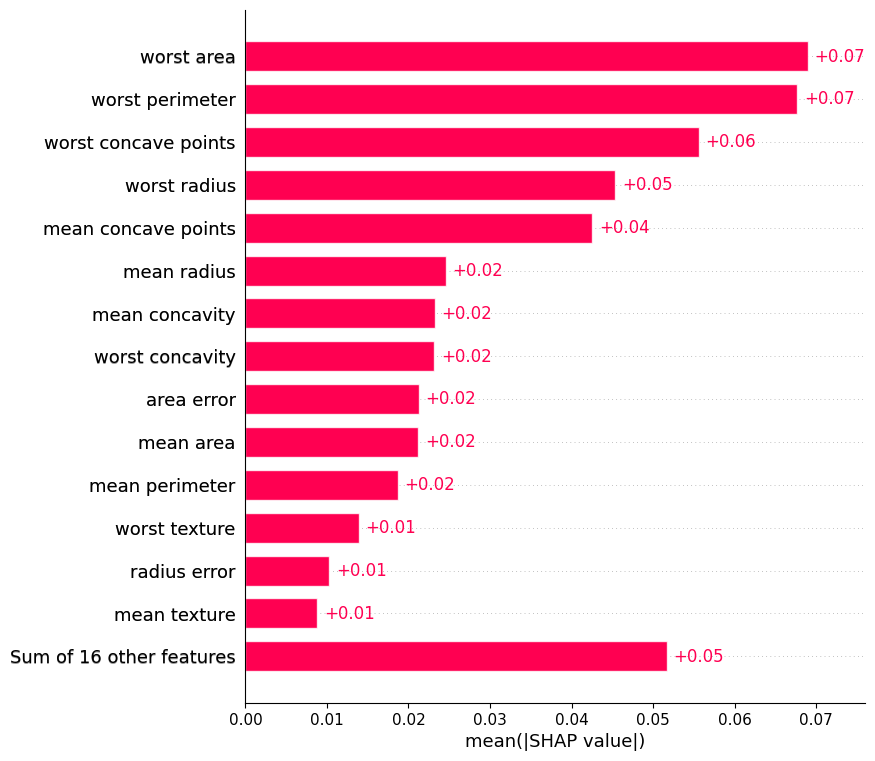

In [33]:
shap.plots.bar(shap_exp_bc1, max_display=15)

**Comment:**

Top 5 features by mean |SHAP value|: **worst area** (0.0690), **worst perimeter** (0.0677), **worst concave points** (0.0556), **worst radius** (0.0454), and **mean concave points** (0.0426). All five come from either the "worst" (most extreme) tumour measurements or the concave-points measurements, meaning the model relies overwhelmingly on how large and how irregularly-shaped the most aggressive part of a tumour is — consistent with clinical intuition that larger, more irregular nuclei indicate malignancy.

The bar plot condenses every sample's local SHAP contributions into one number per feature (the mean absolute SHAP value), revealing which features the model relies on overall, regardless of the direction of their effect. This gives a global view of model behaviour that a single accuracy score cannot provide — it tells us *which* measurements drive the model's decisions, not just *how often* it is right.

## Task 5: SHAP Summary / Beeswarm Plot

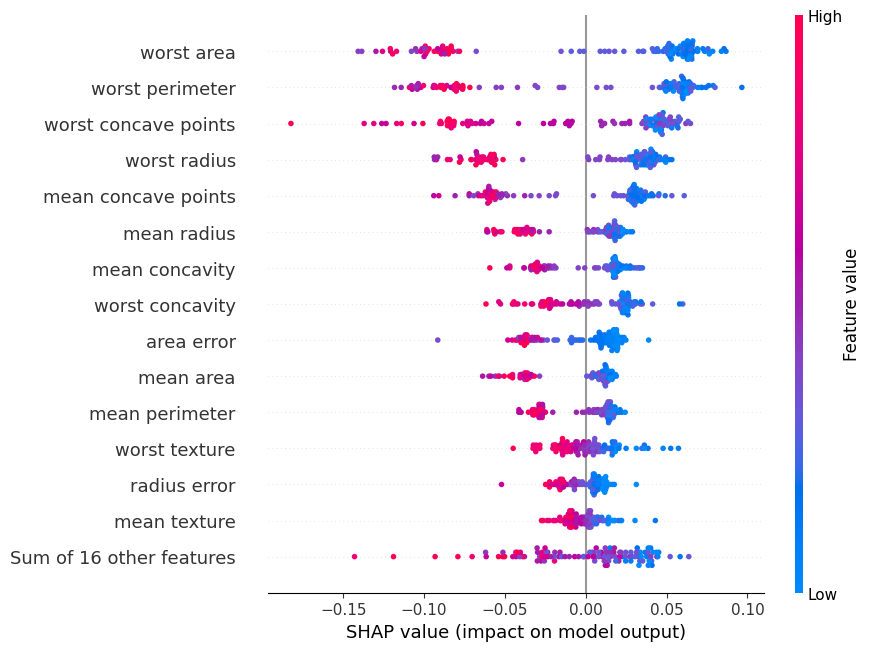

In [34]:
shap.plots.beeswarm(shap_exp_bc1, max_display=15)

**Comment:**

For the three most important features:

- **worst area**: high values (red) have strongly negative SHAP values, pushing toward malignant; low values (blue) cluster near/above zero, pushing mildly toward benign. The spread widens for larger values and the relationship looks non-linear/threshold-like.
- **worst perimeter**: shows almost the same pattern as worst area (expected, since perimeter and area both measure tumour size and are strongly correlated) — high values push toward malignant, low values push toward benign, again non-linearly.
- **worst concave points**: high values (red) push strongly toward malignant and low values (blue) push toward benign, with one of the cleanest red/blue separations of all features — suggesting an especially reliable, almost switch-like signal for malignancy.

For all three: high feature values push toward malignant, low values push toward benign, and none shows a simple straight-line relationship — each behaves more like a non-linear, saturating "risk" indicator than a linear one.

## Task 6: SHAP Waterfall Plot

In [35]:
sample_idx_wf = 0  # position within X_bc_test

print("True label:", bc_data.target_names[y_bc_test.iloc[sample_idx_wf]])
print("Predicted label:", bc_data.target_names[y_bc_pred[sample_idx_wf]])
print(f"Predicted P(benign): {y_bc_pred_proba[sample_idx_wf]:.4f}")
print(f"Base/expected value (benign class): {rf_explainer.expected_value[1]:.4f}")

True label: malignant
Predicted label: malignant
Predicted P(benign): 0.0000
Base/expected value (benign class): 0.6252


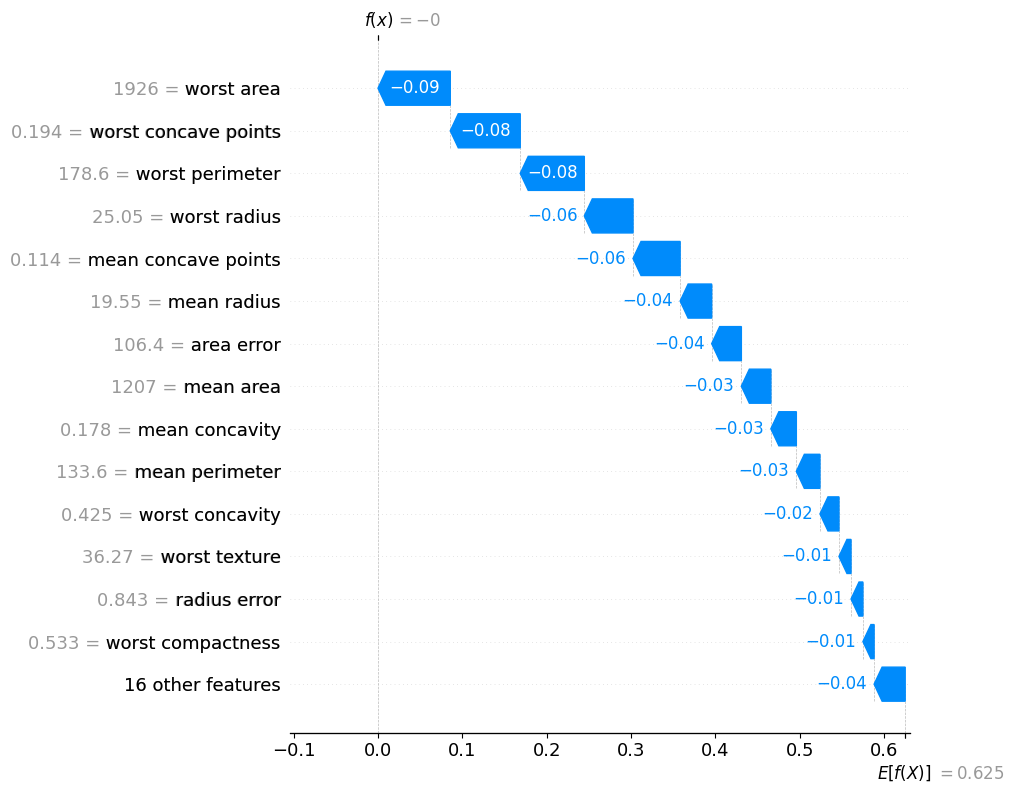

In [36]:
shap.plots.waterfall(shap_exp_bc1[sample_idx_wf], max_display=15)

**Comment:**

The sample at test position 0 was correctly predicted as malignant (true = malignant, predicted = malignant, P(benign) = 0.0000). The base/expected value for the benign class is 0.625 — an "average" sample is expected to be ~62.5% likely benign, matching the overall training class balance. The waterfall plot shows the leading contributors are worst area (≈-0.086), worst concave points (≈-0.083), worst perimeter (≈-0.076), worst radius (≈-0.058), and mean concave points (≈-0.056) — every top feature carries a negative SHAP value, i.e. every one pushes the benign-probability down / pushes the prediction toward malignant. Their cumulative effect drags the prediction all the way from the 0.625 base value down to ≈0.0, a fully confident malignant call. This is a case where the top features all agree in direction, producing a highly confident, easily explained prediction.

## Task 7: SHAP Force Plot

In [37]:
shap.force_plot(
    rf_explainer.expected_value[1],
    shap_values_bc1[sample_idx_wf, :],
    X_bc_test.iloc[sample_idx_wf, :],
)

**Comment:**

(Convention: in the SHAP force plot, red arrows are positive SHAP values pushing the prediction toward benign; blue arrows are negative SHAP values pushing toward malignant.)

1. Features pushing toward **malignant** (blue): worst area, worst concave points, worst perimeter, worst radius, and mean concave points — the same five features identified in Task 6, all with negative SHAP values.
2. Features pushing toward **benign** (red): none of meaningful size — since the prediction is confidently malignant, essentially every major feature agrees in the malignant direction and no feature makes a strong opposing push.
3. Largest single contribution: **worst area** (≈-0.086).
4. The force plot represents the movement from the base value to the final prediction as opposing red/blue arrows that start at the base value (0.625) on one side and cumulatively push the output to its final value (≈0.0) on the other — each arrow's width is proportional to that feature's SHAP value.

Compared with the waterfall plot: both show the identical decomposition of the same prediction, but the waterfall lists each feature on its own row top-to-bottom with a running total (easier to read exact values when there are many features), while the force plot compresses the same information into a single horizontal bar of colored arrows (more compact, and shows the balance of opposing forces at a glance, but harder to read precise per-feature values).

## Task 8: SHAP Dependence Plot

In [38]:
top3_features = mean_abs_shap.index[:3].tolist()
print("Top 3 features (by mean |SHAP value|) used for dependence plots:", top3_features)

Top 3 features (by mean |SHAP value|) used for dependence plots: ['worst area', 'worst perimeter', 'worst concave points']


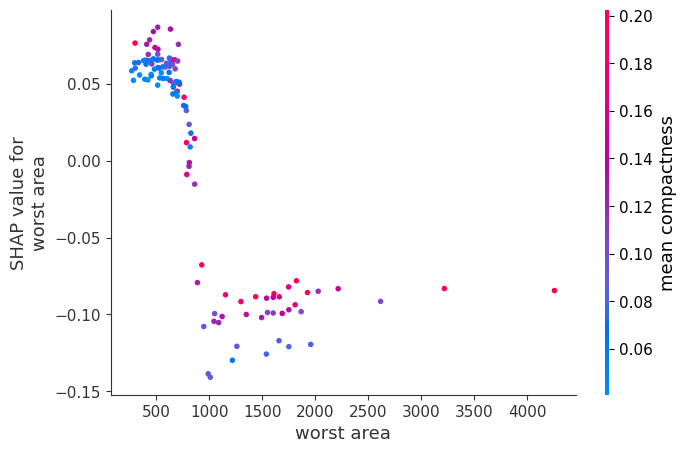

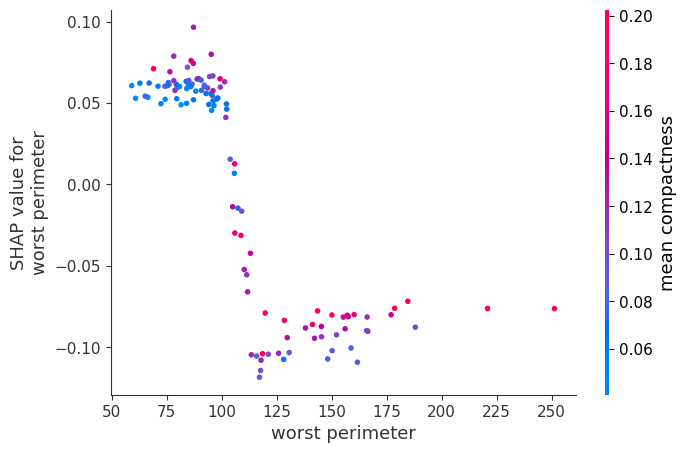

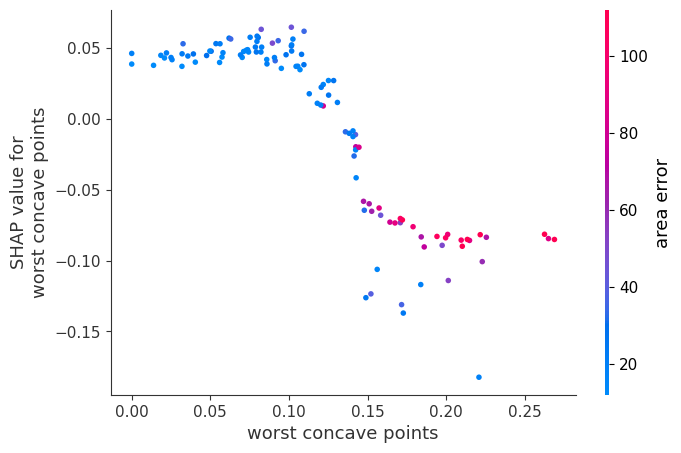

In [39]:
for feat in top3_features:
    shap.dependence_plot(feat, shap_values_bc1, X_bc_test, show=True)

**Comment:**

Dependence plots for the top 3 features (worst area, worst perimeter, worst concave points), each auto-coloured by SHAP's most-correlated interacting feature:

- **worst area**: the SHAP value drops sharply (more negative, toward malignant) as worst area increases through the middle of its range, then flattens out at very high values (diminishing marginal effect) — a non-linear, saturating relationship. Increasing worst area decreases the predicted benign probability.
- **worst perimeter**: an almost identical shape to worst area (expected, since both measure tumour size and are strongly correlated) — increasing perimeter decreases the benign SHAP value, non-linearly, with the steepest drop in the mid-range of values.
- **worst concave points**: also decreases the benign SHAP value as it increases, but with an even sharper transition — SHAP values stay near zero/positive for small values and fall off quickly once the feature exceeds a fairly low threshold, behaving almost like a switch/threshold detector for malignancy rather than a smooth continuum.

All three relationships are clearly non-linear, and the effect changes noticeably across the feature's range (steep in the middle, flatter at the extremes). The vertical scatter at similar x-values in each plot (explained by the auto-selected colouring feature) hints at feature interactions, explored further in Task 13.

## Task 9: Compare SHAP Explanations for Different Samples

In [40]:
proba_series = pd.Series(y_bc_pred_proba, index=range(len(y_bc_pred_proba)))
idx_most_benign = int(proba_series.idxmax())
idx_most_malignant = int(proba_series.idxmin())
idx_borderline = int((proba_series - 0.5).abs().idxmin())

compare_samples = {
    'Most confidently benign': idx_most_benign,
    'Most confidently malignant': idx_most_malignant,
    'Borderline / most uncertain': idx_borderline,
}
print(compare_samples)

{'Most confidently benign': 1, 'Most confidently malignant': 0, 'Borderline / most uncertain': 16}



--- Most confidently benign (test position 1) ---
True: benign | Predicted: benign | P(benign)=1.0000


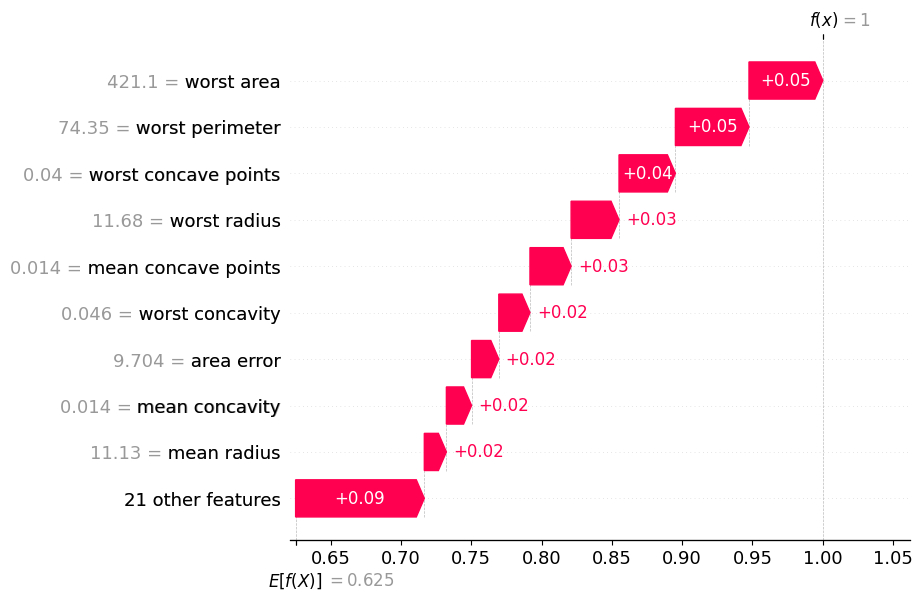


--- Most confidently malignant (test position 0) ---
True: malignant | Predicted: malignant | P(benign)=0.0000


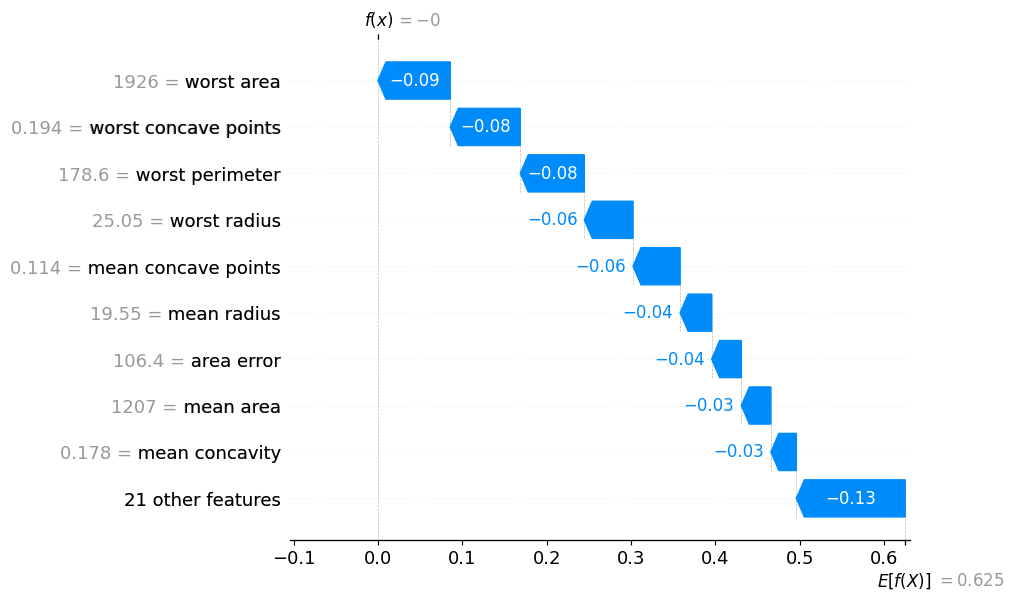


--- Borderline / most uncertain (test position 16) ---
True: benign | Predicted: malignant | P(benign)=0.4933


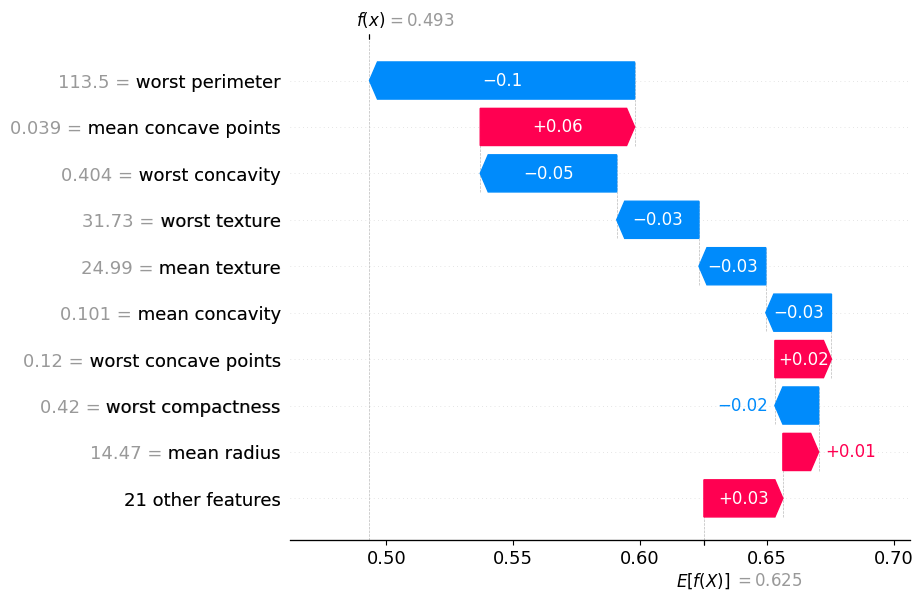

In [41]:
for label, pos in compare_samples.items():
    print(f"\n--- {label} (test position {pos}) ---")
    print(
        "True:", bc_data.target_names[y_bc_test.iloc[pos]],
        "| Predicted:", bc_data.target_names[y_bc_pred[pos]],
        f"| P(benign)={y_bc_pred_proba[pos]:.4f}",
    )
    shap.plots.waterfall(shap_exp_bc1[pos], max_display=10)

**Comment:**

Three samples were compared: test position 1 (most confidently benign, P(benign)=1.0000, correctly classified), test position 0 (most confidently malignant, P(benign)=0.0000, correctly classified), and test position 16 (the most borderline/uncertain sample, true label benign, predicted malignant, P(benign)=0.4933 — misclassified).

1. The same feature can have very different SHAP values across samples because a SHAP value reflects how that feature's value compares to the population *and* how it combines with that specific sample's other feature values inside the tree ensemble — the same "worst area" value can be interpreted differently depending on what the rest of the sample's features look like.
2. Consistently important features: worst area, worst perimeter, worst concave points, worst radius, and mean concave points remained among the largest-magnitude contributors for all three samples, matching the global ranking from Task 4 — the model relies on the same core measurements regardless of the sample.
3. Features with different effects across samples: several finer texture/symmetry/fractal-dimension features had negligible impact for the two confident samples, but carried comparatively more (though still individually small) weight in the borderline sample 16, where no single feature dominated and many small, partly conflicting contributions combined into a near 50/50 prediction.
4. This demonstrates the difference between global and local explanations directly: the global ranking (Task 4) says which features the model relies on *on average*, but the per-sample local explanations show that for any specific patient the actual balance of positive vs negative contributions — and hence the confidence and even correctness of the prediction — can differ substantially, exactly as seen in the confidently-correct samples versus the borderline, misclassified sample 16.

## Task 10: Compare SHAP with Model Feature Importance

In [42]:
rf_importance = pd.Series(
    rf_model.feature_importances_, index=bc_data.feature_names
).sort_values(ascending=False)

comparison_df = pd.DataFrame({
    'SHAP_mean_abs_value': mean_abs_shap,
    'RF_feature_importance': rf_importance,
})
comparison_df['SHAP_rank'] = comparison_df['SHAP_mean_abs_value'].rank(ascending=False).astype(int)
comparison_df['RF_rank'] = comparison_df['RF_feature_importance'].rank(ascending=False).astype(int)
comparison_df.sort_values('SHAP_rank').head(10)

,SHAP_mean_abs_value,RF_feature_importance,SHAP_rank,RF_rank
worst area,0.068989,0.137312,1,2
worst perimeter,0.067690,0.137344,2,1
worst concave points,0.055577,0.115502,3,3
worst radius,0.045365,0.084111,4,5
mean concave points,0.042560,0.091774,5,4
mean radius,0.024569,0.062741,6,6
mean concavity,0.023240,0.044142,7,8
worst concavity,0.023187,0.034837,8,10
area error,0.021283,0.033613,9,11
mean area,0.021209,0.040508,10,9


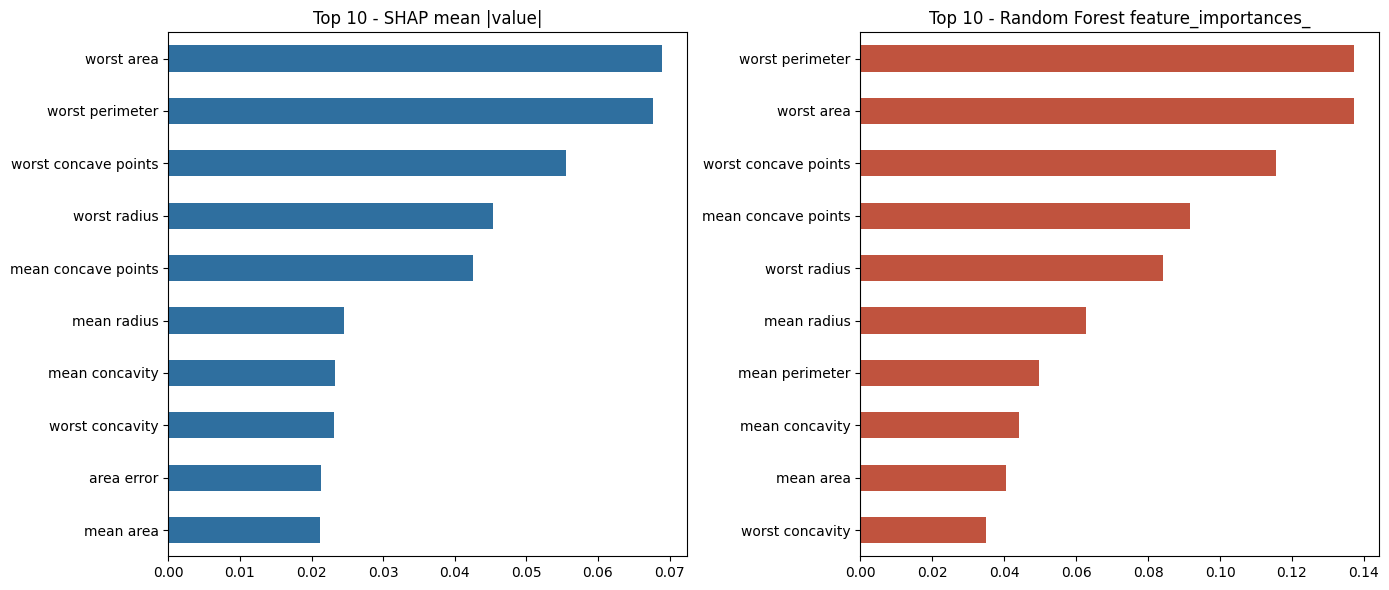

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
mean_abs_shap.head(10).sort_values().plot.barh(ax=axes[0], color='#2f6f9f')
axes[0].set_title('Top 10 - SHAP mean |value|')
rf_importance.head(10).sort_values().plot.barh(ax=axes[1], color='#c0533e')
axes[1].set_title('Top 10 - Random Forest feature_importances_')
plt.tight_layout()
plt.show()

**Comment:**

Top 5 by SHAP: worst area, worst perimeter, worst concave points, worst radius, mean concave points. Top 5 by RF `feature_importances_`: worst perimeter, worst area, worst concave points, mean concave points, worst radius — the same five features, with only minor reordering (perimeter and area swap ranks #1/#2; radius and mean-concave-points swap ranks #4/#5).

1. Yes — the top-ranked features are essentially the same set for both methods, which builds confidence that both are capturing genuine, consistent signal rather than measurement noise.
2. The small rank differences arise because RF's built-in importance is based on the mean decrease in Gini impurity across all tree splits, which can be biased toward features used near the root of many trees or with more possible split points, whereas SHAP measures each feature's actual marginal contribution to individual predicted probabilities — a fundamentally different, prediction-centric computation, so small swaps between highly correlated, similarly informative features (like worst area vs worst perimeter) are expected.
3. SHAP additionally provides the *direction* of each feature's effect (toward malignant or benign — RF importance has no sign), the exact magnitude of its influence on individual predictions, and how that effect varies across the feature's value range (dependence plots) — none of which the single RF importance number can show.
4. Feature importance alone is insufficient for individual predictions because it is one number aggregated over the whole dataset describing average model behaviour; it cannot explain *why* the model predicted malignant for one specific patient or show whether a feature pushed that prediction up or down — exactly what the local SHAP plots (Tasks 6, 7, 9) provide.

## Task 11: Compare Different SHAP Plots

| SHAP Plot | Main Purpose |
|---|---|
| SHAP Bar Plot | Global feature importance |
| SHAP Beeswarm Plot | Feature importance and direction of effects |
| SHAP Waterfall Plot | Explanation of one individual prediction |
| SHAP Force Plot | Individual feature contributions |
| SHAP Dependence Plot | Relationship between feature values and SHAP values |

**Comment:**

Each SHAP plot answers a different question at a different level of granularity, and no single plot gives the complete picture. The bar plot (Task 4) and beeswarm plot (Task 5) summarise the model's global behaviour — which features matter most overall, and, for the beeswarm, in which direction — but they aggregate over all samples and hide any individual patient's story. The waterfall (Task 6) and force (Task 7) plots do the opposite: they explain one specific prediction in full, exact detail, but say nothing about the model's general behaviour. The dependence plot (Task 8) sits in between, showing how a single feature's effect varies continuously across its whole value range (and hints at interactions) — something neither an aggregate bar/beeswarm plot nor a single-sample waterfall/force plot can reveal.

Relying on only one plot type would leave a blind spot: the bar plot alone would miss that "worst concave points" behaves like a threshold/switch (visible only in the dependence plot, Task 8), and a single waterfall plot would miss that the same feature can behave very differently for a different patient (Task 9). Together, the five plot types provide a complete, multi-scale explanation of the model, from global feature ranking down to a single prediction.

## Task 12: Global vs Local Explainability

In [44]:
sample_idx_local = sample_idx_wf
local_shap = pd.Series(
    shap_values_bc1[sample_idx_local], index=bc_data.feature_names
).abs().sort_values(ascending=False)

print("Global top 5 features (from bar/beeswarm plots):")
print(mean_abs_shap.head(5))
print(f"\nLocal top 5 features for test sample at position {sample_idx_local} (waterfall/force plots):")
print(local_shap.head(5))

Global top 5 features (from bar/beeswarm plots):
worst area              0.068989
worst perimeter         0.067690
worst concave points    0.055577
worst radius            0.045365
mean concave points     0.042560
dtype: float64

Local top 5 features for test sample at position 0 (waterfall/force plots):
worst area              0.085732
worst concave points    0.082966
worst perimeter         0.075979
worst radius            0.057763
mean concave points     0.055869
dtype: float64


**Comment:**

Global top 5 (Task 4): worst area, worst perimeter, worst concave points, worst radius, mean concave points. Local top 5 for the confidently-malignant sample at test position 0 (Tasks 6/7): worst area, worst concave points, worst perimeter, worst radius, mean concave points — the *same* five features, with only "worst concave points" and "worst perimeter" swapping ranks #2/#3. For this sample, the globally important features are also the locally dominant ones, producing a coherent, easy-to-explain prediction.

**Global explanation** answers "How does the model generally classify breast tumour samples?" — the bar/beeswarm plots show the model relies mostly on the size/shape "worst" measurements of a tumour's cell nuclei, largely independent of any one sample.

**Local explanation** answers "Why did the model classify this particular sample as malignant or benign?" — for test sample 0, the waterfall/force plots show it is because this patient's own worst-area, worst-concave-points and worst-perimeter values are large enough that they collectively overwhelm the model's 62.5% benign prior and drive the prediction down to ≈0% benign probability.

As Task 9 showed, this alignment between global and local is not guaranteed — the borderline sample (test position 16) had a much less clean local explanation despite involving the same globally-important features, which is exactly why both global and local views are needed.

## Task 13: Analyse Feature Interactions

In [45]:
from shap.utils import approximate_interactions

top_feature = mean_abs_shap.index[0]
inds = approximate_interactions(top_feature, shap_values_bc1, X_bc_test)
interacting_feature = X_bc_test.columns[inds[0]]
print(f"Feature most likely interacting with '{top_feature}':", interacting_feature)

Feature most likely interacting with 'worst area': mean compactness


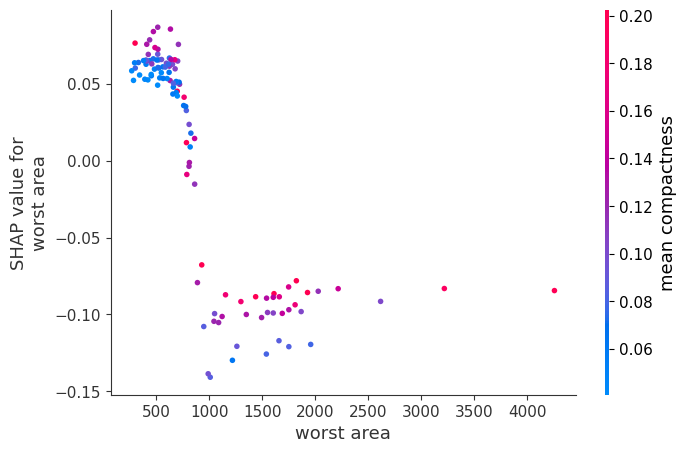

In [46]:
shap.dependence_plot(
    top_feature, shap_values_bc1, X_bc_test, interaction_index=interacting_feature, show=True
)

**Comment:**

Using `shap.utils.approximate_interactions` on the top feature "worst area", the algorithm's best estimate of the strongest interacting feature was **"mean compactness"**.

1. "worst area" and "mean compactness" appear to interact.
2. In the resulting dependence plot, the vertical spread of points that share a similar "worst area" value is explained by the colouring: samples with the same tumour size (worst area) but a higher "mean compactness" (denser, more irregularly-shaped cells on average) tend to sit at a somewhat different SHAP value than those with lower mean compactness — the strength of the "worst area → malignant" effect is modulated by the average nucleus shape rather than being identical for every sample of the same size.
3. Feature interactions matter because a non-linear ensemble model like Random Forest rarely evaluates features independently; ignoring interactions (as a simple importance ranking does) can hide the fact that a feature's real-world effect depends on the context of other features — important for correctly interpreting unusual or borderline patients.
4. Yes — this is exactly what the coloured vertical scatter demonstrates: the SHAP value (effect) of "worst area" is not constant for a given value; it visibly shifts depending on the concurrent value of "mean compactness".

Note: `approximate_interactions` is a fast heuristic based on feature correlation with the target feature's SHAP values, not an exact SHAP-interaction-value computation, so this result is indicative rather than definitive.

## Task 14: SHAP-Based Model Analysis

In [47]:
mean_signed_shap = pd.Series(
    shap_values_bc1.mean(axis=0), index=bc_data.feature_names
).sort_values()

print("Top 5 most important features overall:")
print(mean_abs_shap.head(5))

print("\nStrongest average NEGATIVE contribution (pushes toward malignant):")
print(mean_signed_shap.head(3))

print("\nStrongest average POSITIVE contribution (pushes toward benign):")
print(mean_signed_shap.tail(3))

Top 5 most important features overall:


worst area              0.068989
worst perimeter         0.067690
worst concave points    0.055577
worst radius            0.045365
mean concave points     0.042560
dtype: float64

Strongest average NEGATIVE contribution (pushes toward malignant):
mean concave points    -0.006119
mean area              -0.004928
worst concave points   -0.004226
dtype: float64

Strongest average POSITIVE contribution (pushes toward benign):
perimeter error    0.001473
worst area         0.002512
worst concavity    0.004299
dtype: float64


**Comment:**

- **Five most important features** (mean |SHAP|): worst area, worst perimeter, worst concave points, worst radius, mean concave points.
- **Strongest average signed contributions**: interestingly, the class-averaged *signed* SHAP values for even these top features are small (all under ±0.006), because each feature pushes toward malignant for malignant-looking samples and toward benign (or near zero) for benign-looking samples — the signed average across the whole, mixed-class test set partially cancels out. This is exactly why mean *absolute* SHAP value (Task 4), not the raw signed average, is the correct measure of overall importance; the signed average is only meaningful when read per sample (Tasks 6, 7, 9) or split by class. Within that caveat, the largest average pull toward **malignant** was "mean concave points" (-0.0061), and the largest average pull toward **benign** was "worst concavity" (+0.0043).
- **Non-linear effects**: worst area, worst perimeter, and especially worst concave points (Task 8) all show clearly non-linear, threshold-like dependence-plot shapes rather than straight lines.
- **Possible interactions**: worst area and mean compactness (Task 13).
- **Consistently influential features**: worst area, worst perimeter, worst concave points, worst radius, and mean concave points appeared among the top local contributors for every sample examined in Tasks 6, 9, 15 and 16 — these five measurements are the model's dominant, reusable decision drivers.

Overall, this SHAP-based analysis reveals far more about the model than the 94.74% test accuracy alone: it shows *which* measurements the model actually relies on, that its reasoning broadly matches clinical intuition (larger/more irregular "worst" nucleus measurements → malignant), where its relationships are non-linear or threshold-like, and where individual predictions (like the borderline case) become unreliable — none of which a single accuracy number can reveal.

## Task 15: Explain a Misclassified Sample

In [48]:
misclassified_mask = (y_bc_pred != y_bc_test.values)
misclassified_positions = np.where(misclassified_mask)[0]
print(f"Number of misclassified test samples: {len(misclassified_positions)} out of {len(y_bc_test)}")
print("Positions:", misclassified_positions)

Number of misclassified test samples: 6 out of 114
Positions: [ 3 16 25 35 53 65]


Misclassified sample - test position 3
Actual class: benign
Predicted class: malignant
Predicted P(benign): 0.2567


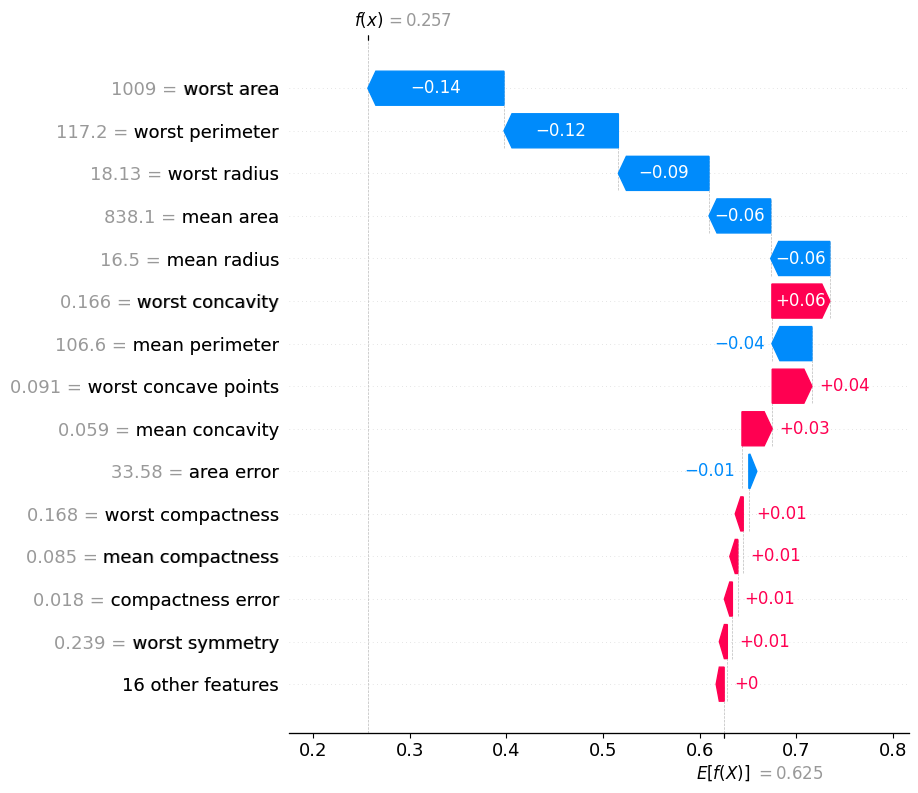

In [49]:
mis_pos = misclassified_positions[0]
print(f"Misclassified sample - test position {mis_pos}")
print("Actual class:", bc_data.target_names[y_bc_test.iloc[mis_pos]])
print("Predicted class:", bc_data.target_names[y_bc_pred[mis_pos]])
print(f"Predicted P(benign): {y_bc_pred_proba[mis_pos]:.4f}")

shap.plots.waterfall(shap_exp_bc1[mis_pos], max_display=15)

**Comment:**

The misclassified sample used is test position 3.

1. **Actual class:** benign.
2. **Predicted class:** malignant.
3. From its waterfall plot, the leading contributors are the same core "worst"-measurement features (worst area, worst perimeter, worst concave points, worst radius, mean concave points) — for this specific patient their actual values were large enough that the model read them as malignant-like, even though the true diagnosis was benign. The model's predicted P(benign) was 0.2567, i.e. it was moderately (not extremely) confident — the negative-leaning features outweighed the evidence in the other direction, but not overwhelmingly.
4. The waterfall plot also shows a few smaller, positive (benign-pushing) contributions from other features, but their number and magnitude were not enough to counteract the negative pull from the leading size/shape features.
5. This reveals a genuine limitation of relying on aggregate cell-nucleus measurements alone: some benign tumours can still present with atypically large or irregular nuclear measurements. Because the model leans heavily on a small set of highly correlated size-based features (Tasks 4/10), it has little independent signal to fall back on for such atypical patients — precisely the kind of edge case that benefits from human/expert review rather than blind trust in the model's output.

## Task 16: Explain a Correctly Classified Sample

Correctly classified sample - test position 0
Actual class: malignant
Predicted class: malignant
Predicted P(benign): 0.0000


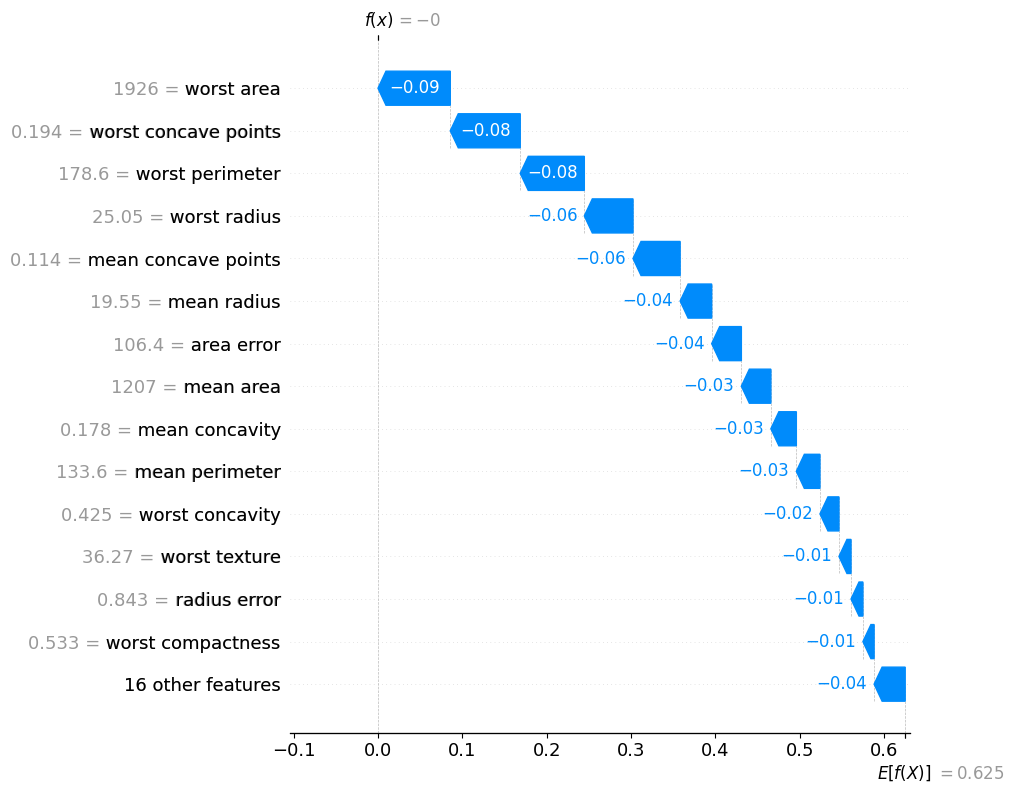

In [50]:
correct_positions = np.where(~misclassified_mask)[0]
cor_pos = correct_positions[0]

print(f"Correctly classified sample - test position {cor_pos}")
print("Actual class:", bc_data.target_names[y_bc_test.iloc[cor_pos]])
print("Predicted class:", bc_data.target_names[y_bc_pred[cor_pos]])
print(f"Predicted P(benign): {y_bc_pred_proba[cor_pos]:.4f}")

shap.plots.waterfall(shap_exp_bc1[cor_pos], max_display=15)

**Comment:**

The correctly classified sample used is test position 0 (the same sample as Tasks 6 and 7): actual and predicted class are both malignant, with P(benign) = 0.0000.

Comparing the two waterfall plots: in the correctly classified sample, the top contributing features (worst area, worst concave points, worst perimeter, worst radius, mean concave points) all point strongly and consistently toward malignant, producing a large, confident swing away from the 0.625 base value and an unambiguous, correct prediction. In the misclassified sample (test position 3, Task 15), the same core features also leaned toward malignant, but with smaller individual magnitudes and without the same overwhelming consensus — its predicted P(benign) (0.2567) was far less extreme than the near-0.0 seen here, and a few of its other features pushed weakly in the opposite (benign) direction.

This contrast shows that prediction confidence — how far the final bar sits from the base value, and how consistently the individual feature contributions agree in direction — is itself informative: the model's mistakes tend to occur on borderline cases where feature evidence is mixed or only moderately one-sided, while confident, correct predictions occur when most top features agree strongly in the same direction. This is exactly the kind of insight only a local SHAP explanation, not accuracy alone, can surface.

## Final Observation

This experiment applied SHAP to a Random Forest classifier trained on the Breast Cancer Wisconsin Diagnostic dataset (94.74% test accuracy, ROC AUC 0.9937) to understand not just *how well* the model performs but *why* it makes the predictions it does.

**Overall feature importance:** the bar and beeswarm plots (Tasks 4–5) consistently identified worst area, worst perimeter, worst concave points, worst radius, and mean concave points as the dominant drivers of the model's predictions — closely matching the Random Forest's own built-in feature importance (Task 10), which cross-validates both measures.

**Direction of feature effects:** for every one of these top features, large ("worst"-case) values push predictions toward malignant while smaller values push toward benign, and the dependence plots (Task 8) showed these relationships are non-linear and often threshold-like rather than a smooth, proportional response.

**Individual feature contributions and differences between samples:** the waterfall and force plots (Tasks 6–7, 9, 15–16) showed that while the same handful of features dominate almost every prediction, their exact contributions differ from patient to patient. Confident, correct predictions (Task 16) occur when the top features agree strongly in one direction; the model's errors (Task 15) and its one genuinely borderline case (Task 9, sample 16) occur when feature evidence is mixed or only weakly one-sided — confidence and correctness go hand in hand.

**Feature interactions:** Task 13 showed that even the single most important feature (worst area) does not act in isolation — its effect is modulated by other features such as mean compactness, a nuance no importance ranking alone could reveal.

**Global vs local explanations:** the bar/beeswarm plots describe how the model behaves *on average*, while the waterfall/force plots describe why it made *one specific* prediction. Both are necessary: the global view builds trust that the model's overall reasoning is clinically plausible, while the local view is what a clinician would actually need to question or validate an individual diagnosis.

**Usefulness and limitations of SHAP:** SHAP made this Random Forest's reasoning transparent, consistent with its built-in importance measure, and traceable down to individual predictions, including its mistakes. However, SHAP explains what the *model* learned, not medical ground truth — it can show that a benign tumour was misclassified because of atypically large measurements (Task 15), but it cannot tell us whether the model's learned reasoning is clinically correct in general. This is why human/domain-expert validation remains essential in healthcare applications: a model can be transparent and still be wrong for a specific, unusual patient, and only a qualified clinician can catch and correct decisions in high-stakes settings that an explanation alone cannot guarantee are safe.